# UMA Workflow

This notebook implements the general workflow for a UMA calculation, visualization, and then attack.

### Optional: Jupyter/VS Code notebook kernel

If you want to run this notebook locally, register your UMA virtual environment as a notebook kernel:

```bash
python -m pip install ipykernel
```

Then open this notebook in VS Code or Jupyter and select the venv that supports UMA.

## Calculation

In [4]:
import torch
from pathlib import Path

from mlff_attack.relaxation import (
    load_structure,
    setup_calculator,
    run_relaxation,
    save_results,
)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

input_cif = Path("../Tl4SnTe3.cif")
outdir = Path("output")
traj_path = outdir / "relaxed.traj"
outdir.mkdir(parents=True, exist_ok=True)

In [6]:
atoms = load_structure(input_cif)

if atoms is None:
    raise RuntimeError(f"Failed to load structure from {input_cif}")

atoms

Atoms(symbols='Tl16Sn4Te12', pbc=True, cell=[8.94082, 8.94082, 13.36387], spacegroup_kinds=...)

In [7]:
atoms = setup_calculator(
    atoms,
    "uma-s-1p1",
    device=device,
    calculator="uma",
    uma_task="omat",
    verbose=True,
)

if atoms is None:
    raise RuntimeError("UMA calculator setup failed. Check Hugging Face auth/access.")

atoms

W0528 21:03:38.924000 1636 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Atoms(symbols='Tl16Sn4Te12', pbc=True, cell=[8.94082, 8.94082, 13.36387], spacegroup_kinds=..., calculator=FAIRChemCalculator(...))

In [8]:
energy = atoms.get_potential_energy()
forces = atoms.get_forces()

print("Energy:", energy)
print("Max force:", (forces**2).sum(axis=1).max() ** 0.5)

Energy: -98.0479313485033
Max force: 0.029220402


In [9]:
success = run_relaxation(
    atoms,
    traj_path=traj_path,
    fmax=0.01,
    max_steps=300,
    optimizer="LBFGS",
)
success

True

In [10]:
save_results(atoms, outdir)

WindowsPath('output/relaxed.cif')

## Visualization

In [11]:
from mlff_attack.visualization import load_trajectory, create_visualization

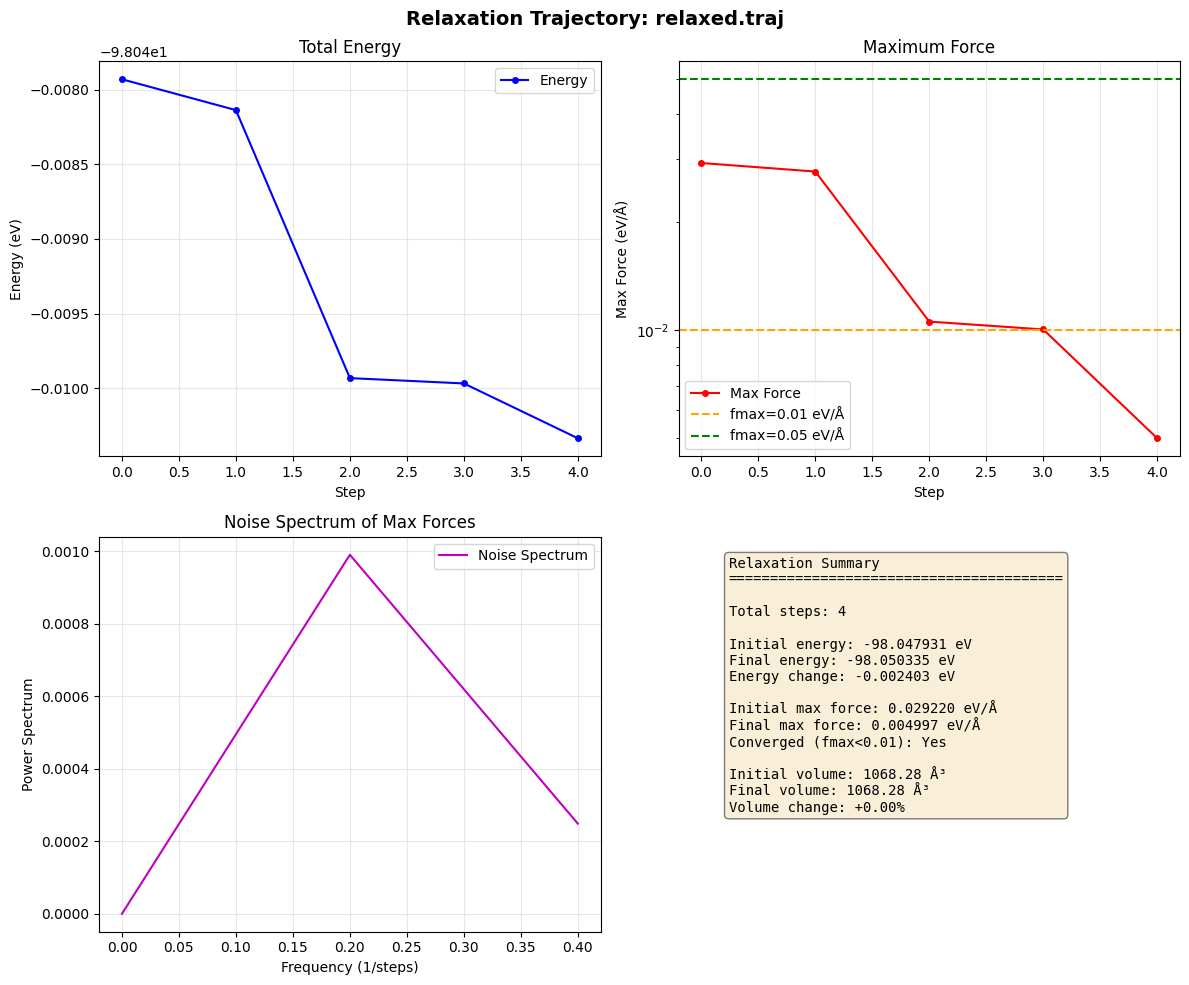

'output\\relaxation_analysis.png'

In [12]:
traj = load_trajectory(traj_path)

if traj is None:
    raise RuntimeError(f"Could not load trajectory from {traj_path}")

visualization_path = create_visualization(
    traj=traj,
    traj_path=traj_path,
    outdir=outdir,
    output_format="png",
    show=True,
)

visualization_path

## Attack

In [13]:
import matplotlib.pyplot as plt
from mlff_attack.attacks import make_attack, visualize_perturbation

In [16]:
outdir = Path("output")
relaxed_cif = outdir / "relaxed.cif"
attack_outdir = Path("output_perturbed")
attack_outdir.mkdir(parents=True, exist_ok=True)

output_cif = attack_outdir / "relaxed_perturbed.cif"

In [17]:
attack_atoms = load_structure(relaxed_cif)

if attack_atoms is None:
    raise RuntimeError(f"Failed to load relaxed structure from {relaxed_cif}")

output_file, perturbed_atoms, attack_details = make_attack(
    atoms=attack_atoms,
    model_path="uma-s-1p1",
    device=device,
    output_cif=output_cif,
    attack_type="fgsm",
    epsilon=0.05,
    n_steps=1,
    target_energy=None,
    clip=True,
    calculator="uma",
    uma_task="omat",
    uma_charge=0,
    uma_spin=1,
)

output_file

'output_perturbed\\relaxed_perturbed.cif'

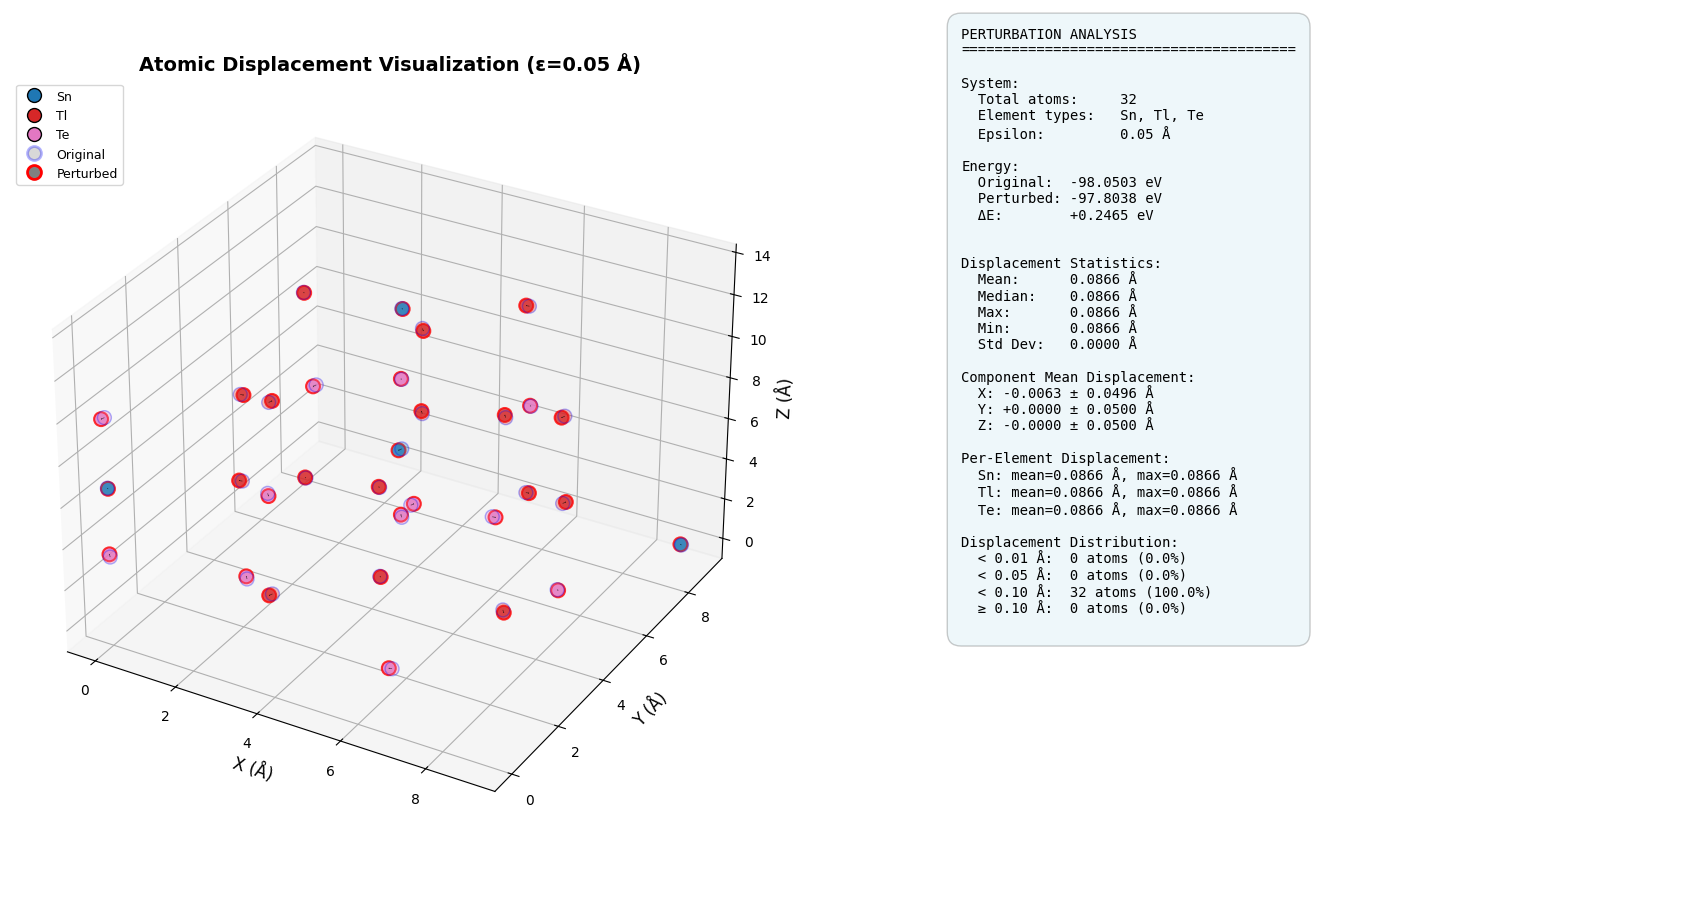

In [18]:
fig = visualize_perturbation(
    attack_atoms,
    perturbed_atoms,
    epsilon=0.05,
    outdir=attack_outdir,
)
plt.show()